# Student Depression Dataset - EDA

## Project: Deep Learning / ANN

In this notebook, I explore the Student Depression Dataset before building a neural network model.

The goal is to understand:
- the structure of the dataset
- the target variable: Depression
- missing values
- class balance
- relationships between variables
- important patterns that may help an ANN model

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Nice visual style
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Custom palette for prettier plots
palette = ["#6C63FF", "#FF6584", "#2EC4B6", "#F9C74F", "#90BE6D", "#F8961E"]

print("Libraries imported successfully!")

Libraries imported successfully!


In [27]:
possible_paths = [
    Path("../../data/raw/Student Depression Dataset.csv"),
    Path("../../data/Student Depression Dataset.csv"),
    Path("../data/raw/Student Depression Dataset.csv"),
    Path("../data/Student Depression Dataset.csv"),
    Path("Student Depression Dataset.csv"),
]

csv_path = None

for path in possible_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError(
        "CSV file not found. Please check where 'Student Depression Dataset.csv' is saved."
    )

df = pd.read_csv(csv_path)

print(f"Dataset loaded from: {csv_path}")
print(f"Shape: {df.shape}")

df.head()

Dataset loaded from: ..\..\data\Student Depression Dataset.csv
Shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [29]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [30]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,27901.0,70442.149421,40641.175216,2.0,35039.00,70684.00,105818.00,140699.0
Age,27901.0,25.822300,4.905687,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141214,1.381465,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000430,0.043992,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.943837,1.361148,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.000681,0.044394,0.0,0.00,0.00,0.00,4.0
Work/Study Hours,27901.0,7.156984,3.707642,0.0,4.00,8.00,10.00,12.0
Financial Stress,27898.0,3.139867,1.437347,1.0,2.00,3.00,4.00,5.0
Depression,27901.0,0.585499,0.492645,0.0,0.00,1.00,1.00,1.0


In [32]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percent": missing_percent
})

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Missing Percent
Financial Stress,3,0.010752


In [33]:
duplicates = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicates}")

Number of duplicated rows: 0


In [34]:
target_counts = df["Depression"].value_counts().sort_index()
target_percent = df["Depression"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percent": target_percent.round(2)
})

target_summary

,Count,Percent
Depression,,
0,11565,41.45
1,16336,58.55


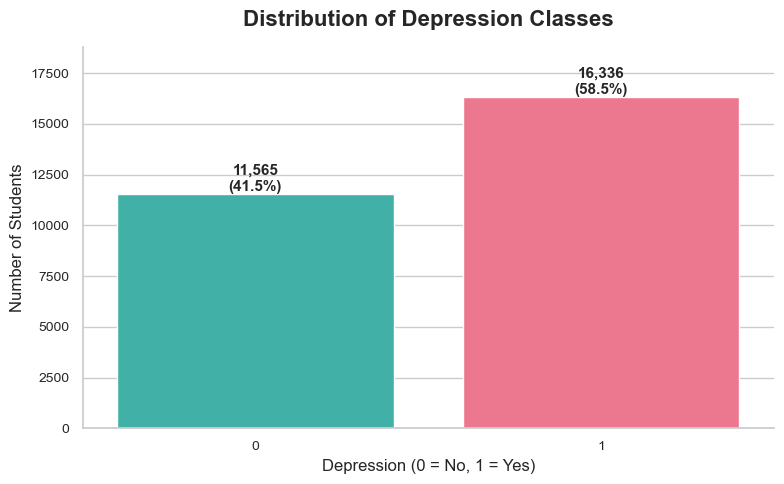

In [35]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Depression",
    hue="Depression",
    palette=["#2EC4B6", "#FF6584"],
    legend=False
)

plt.title("Distribution of Depression Classes", weight="bold", pad=15)
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Number of Students")

total = len(df)
max_height = max([p.get_height() for p in ax.patches])
plt.ylim(0, max_height * 1.15)

for p in ax.patches:
    height = p.get_height()
    percentage = 100 * height / total
    ax.annotate(
        f"{int(height):,}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

## Target Variable: Depression

The target variable is `Depression`, where:

- `0` means the student is not classified as depressed
- `1` means the student is classified as depressed

This is a binary classification problem, which means that the ANN model will predict one of two possible classes.

Since this dataset contains sensitive mental health information, the model should be seen as a support tool for identifying risk patterns, not as a medical diagnosis tool.

In [36]:
data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Unique Values": df.nunique().values
})

data_types.sort_values("Unique Values")

,Column,Data Type,Unique Values
17,Depression,int64,2
1,Gender,object,2
13,Have you ever had suicidal thoughts ?,object,2
16,Family History of Mental Illness,object,2
6,Work Pressure,float64,3
11,Dietary Habits,object,4
15,Financial Stress,float64,5
10,Sleep Duration,object,5
9,Job Satisfaction,float64,5
8,Study Satisfaction,float64,6


In [37]:
target_col = "Depression"

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

Categorical columns:
['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [38]:
df.shape
df.head()
missing_df[missing_df["Missing Values"] > 0]
target_summary

,Count,Percent
Depression,,
0,11565,41.45
1,16336,58.55


In [39]:
def plot_depression_rate_by_category(data, column, title=None, figsize=(10, 5), rotation=30):
    """
    Plot depression rate by category.
    Shows the percentage of students with Depression = 1 for each category.
    """
    rate_df = (
        data.groupby(column)["Depression"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    
    rate_df["Depression Rate (%)"] = rate_df["Depression"] * 100
    
    plt.figure(figsize=figsize)
    
    ax = sns.barplot(
        data=rate_df,
        x=column,
        y="Depression Rate (%)",
        hue=column,
        palette="viridis",
        legend=False
    )
    
    plt.title(title or f"Depression Rate by {column}", weight="bold", pad=15)
    plt.xlabel(column)
    plt.ylabel("Depression Rate (%)")
    plt.xticks(rotation=rotation, ha="right")
    plt.ylim(0, min(100, rate_df["Depression Rate (%)"].max() * 1.2))
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            weight="bold"
        )
    
    sns.despine()
    plt.tight_layout()
    plt.show()

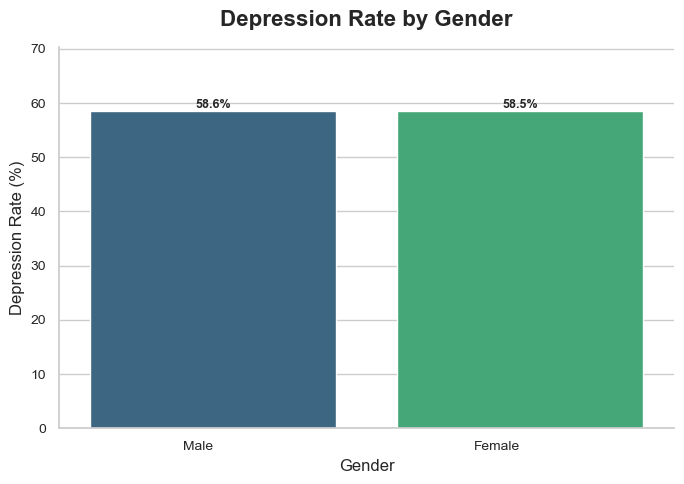

In [40]:
plot_depression_rate_by_category(
    df,
    "Gender",
    title="Depression Rate by Gender",
    figsize=(7, 5),
    rotation=0
)

### Gender and Depression

This chart shows the percentage of students classified as depressed within each gender group.  
It helps us understand whether depression rates differ between male and female students in this dataset.

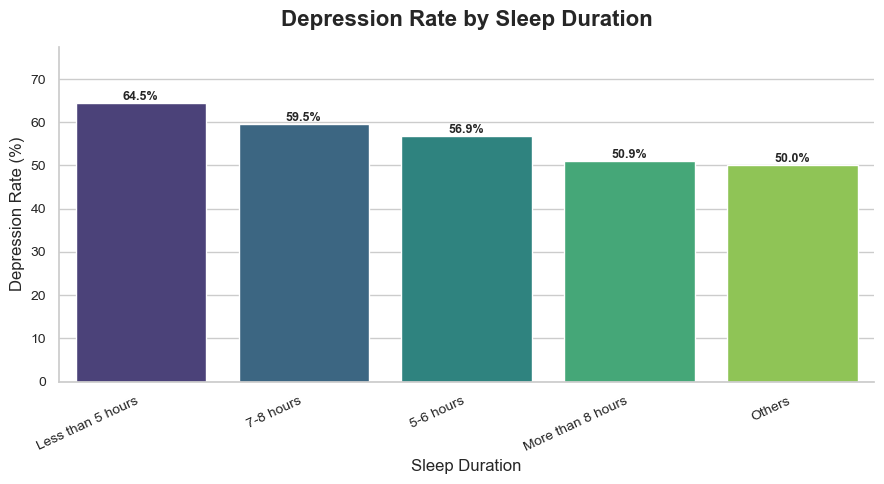

In [41]:
plot_depression_rate_by_category(
    df,
    "Sleep Duration",
    title="Depression Rate by Sleep Duration",
    figsize=(9, 5),
    rotation=25
)

### Sleep Duration and Depression

Sleep duration is an important lifestyle factor.  
This chart helps us see whether students with shorter or irregular sleep patterns have higher depression rates.

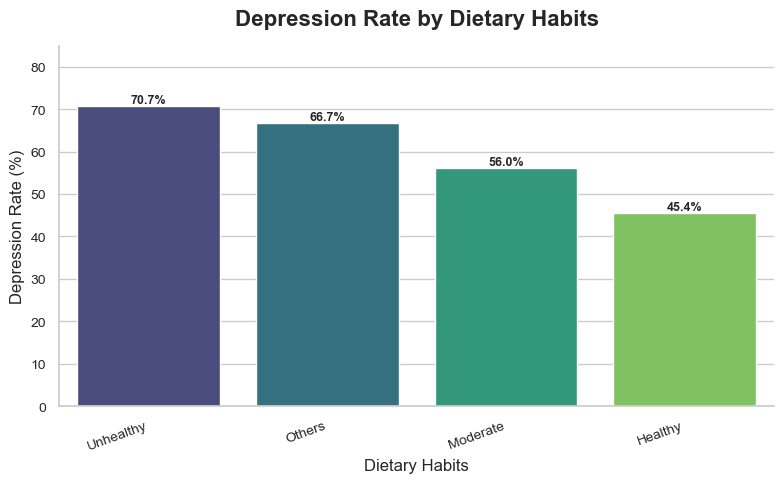

In [42]:
plot_depression_rate_by_category(
    df,
    "Dietary Habits",
    title="Depression Rate by Dietary Habits",
    figsize=(8, 5),
    rotation=20
)

### Dietary Habits and Depression

Dietary habits may be connected to general lifestyle and wellbeing.  
This chart shows whether depression rates differ between students with healthy, moderate or unhealthy dietary habits.

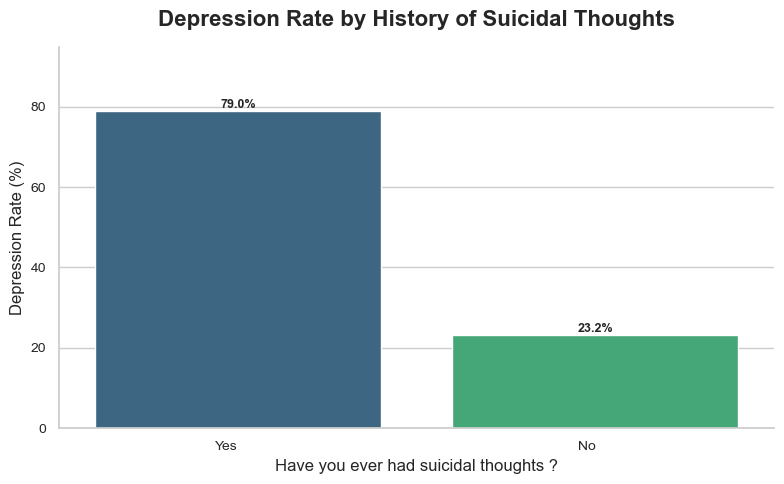

In [43]:
plot_depression_rate_by_category(
    df,
    "Have you ever had suicidal thoughts ?",
    title="Depression Rate by History of Suicidal Thoughts",
    figsize=(8, 5),
    rotation=0
)

### Suicidal Thoughts and Depression

This variable is very sensitive and should be interpreted carefully.  
The chart shows whether students who answered "Yes" to having had suicidal thoughts have a higher depression rate in the dataset.

This does not mean the model should be used as a diagnosis tool. It should only be used to understand risk patterns and support responsible student wellbeing analysis.

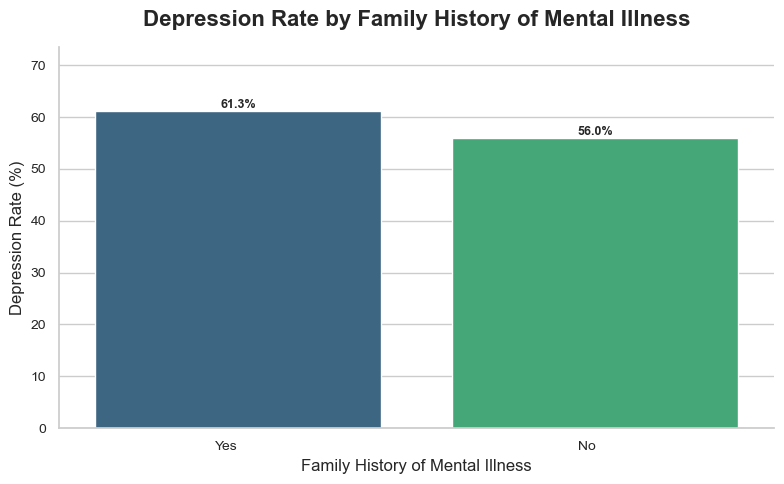

In [44]:
plot_depression_rate_by_category(
    df,
    "Family History of Mental Illness",
    title="Depression Rate by Family History of Mental Illness",
    figsize=(8, 5),
    rotation=0
)

### Family History and Depression

Family history of mental illness may be related to mental health risk factors.  
This chart helps us compare depression rates between students with and without a family history of mental illness.

In [45]:
numerical_cols

['id',
 'Age',
 'Academic Pressure',
 'Work Pressure',
 'CGPA',
 'Study Satisfaction',
 'Job Satisfaction',
 'Work/Study Hours',
 'Financial Stress']

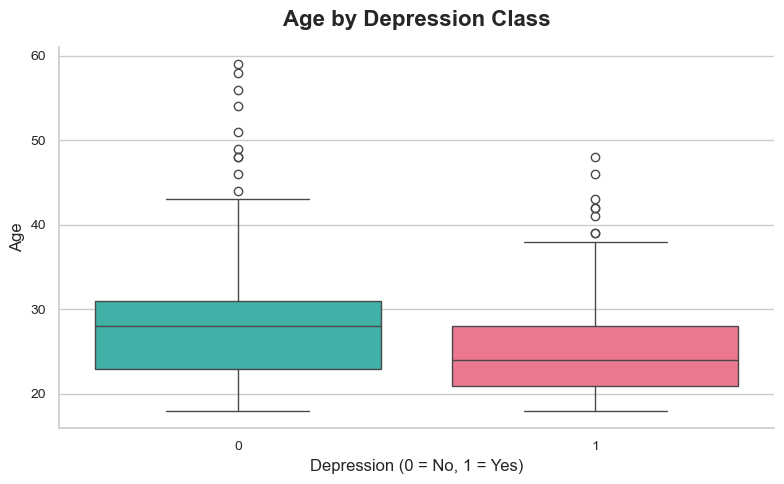

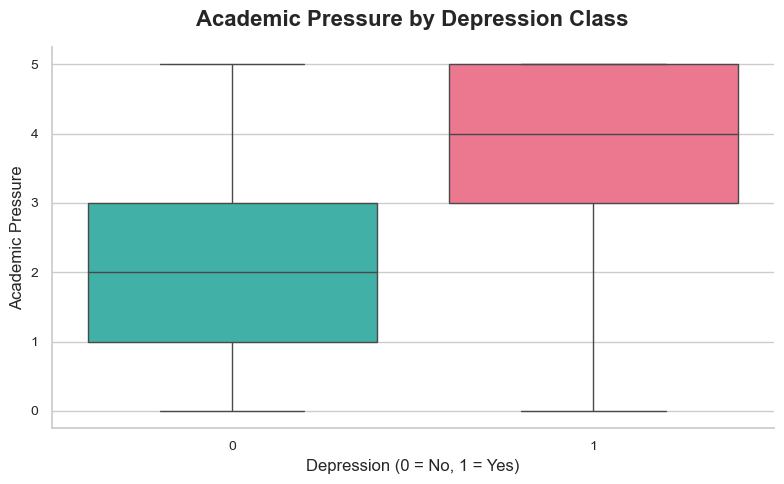

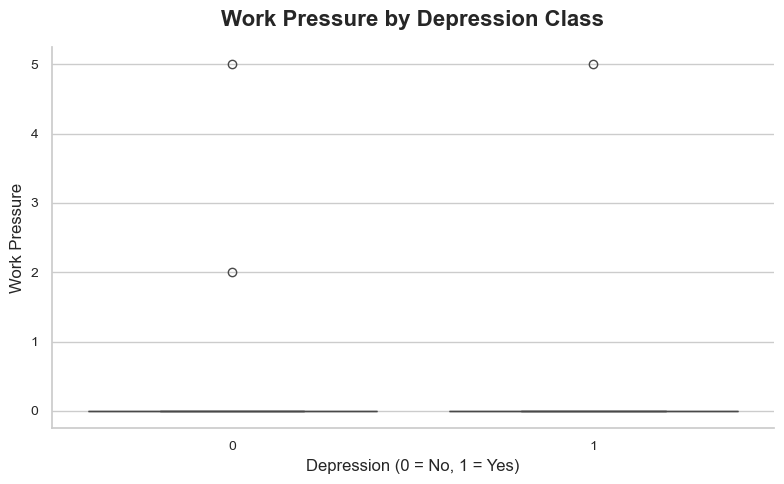

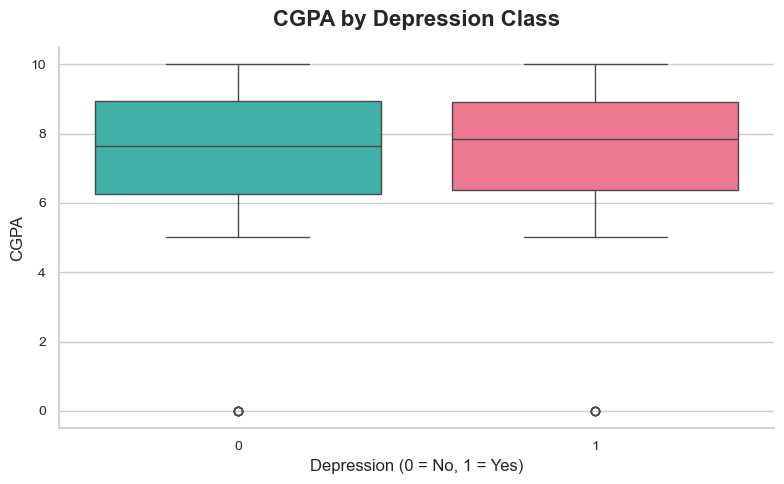

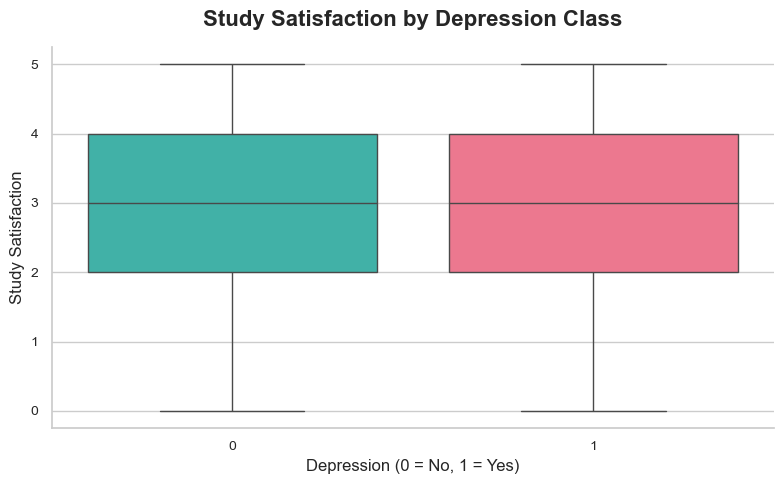

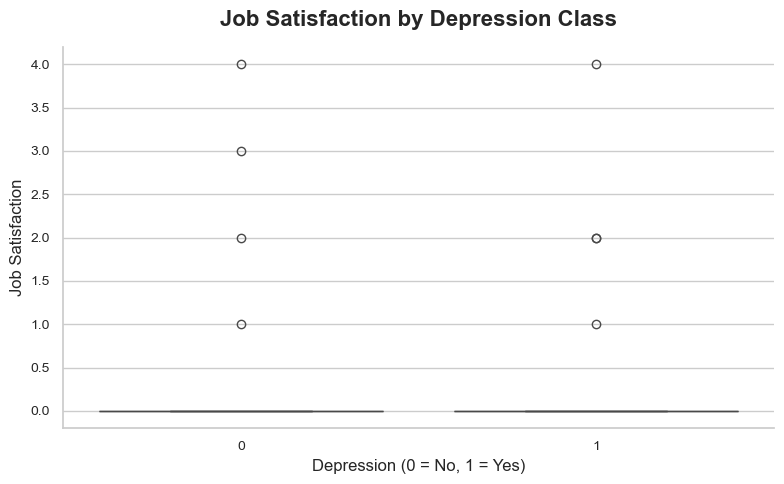

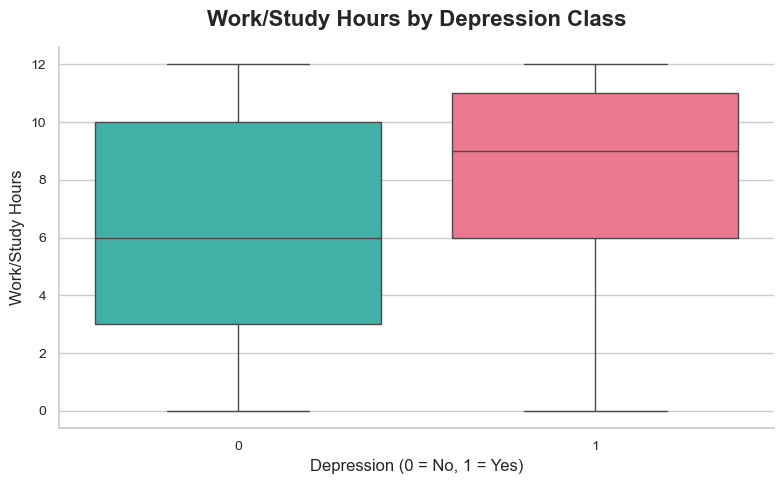

KeyboardInterrupt: 

In [46]:
important_numeric_cols = [
    "Age",
    "Academic Pressure",
    "Work Pressure",
    "CGPA",
    "Study Satisfaction",
    "Job Satisfaction",
    "Work/Study Hours",
    "Financial Stress"
]

for col in important_numeric_cols:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=df,
        x="Depression",
        y=col,
        hue="Depression",
        palette=["#2EC4B6", "#FF6584"],
        legend=False
    )
    
    plt.title(f"{col} by Depression Class", weight="bold", pad=15)
    plt.xlabel("Depression (0 = No, 1 = Yes)")
    plt.ylabel(col)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

### Numerical Variables and Depression

The boxplots compare the distribution of numerical variables between students without depression and students with depression.

This helps us identify whether variables such as academic pressure, study satisfaction, work/study hours and financial stress differ between the two groups.

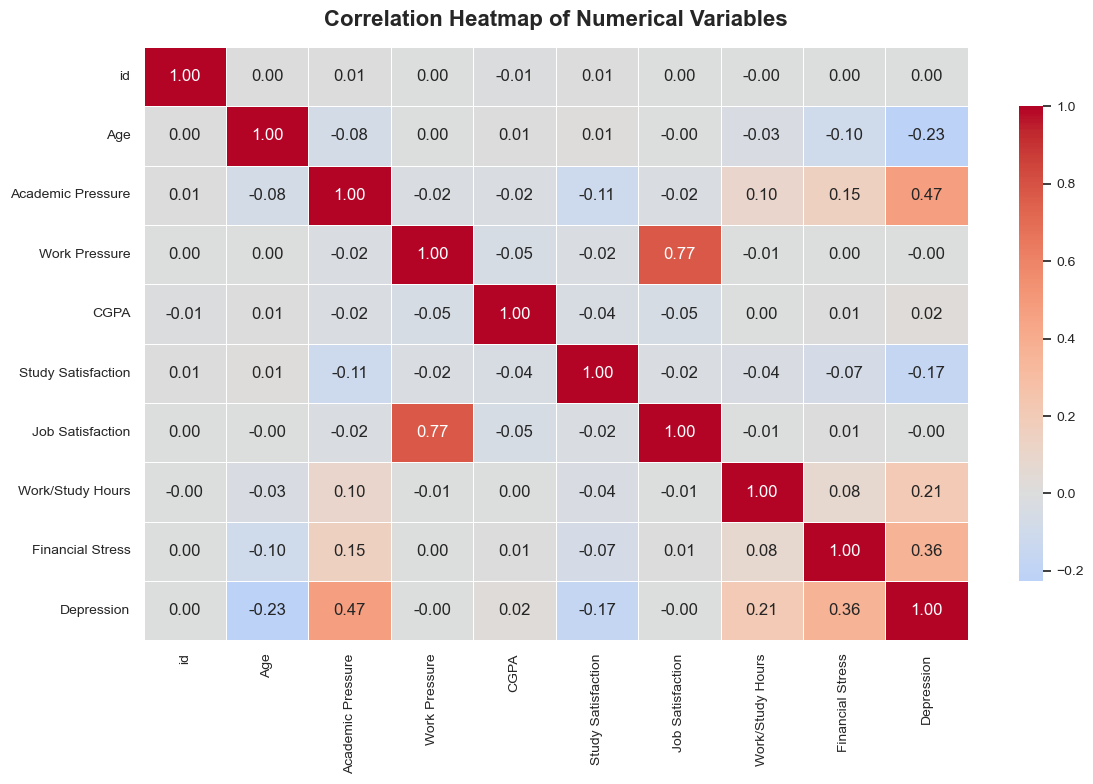

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Numerical Variables", weight="bold", pad=15)
plt.tight_layout()
plt.show()

### Correlation Heatmap

The correlation heatmap shows linear relationships between numerical variables.

For this project, the most important correlations are the relationships between each numerical feature and the target variable `Depression`.

A positive correlation with Depression means that higher values of the variable are associated with a higher depression class.  
A negative correlation means that higher values are associated with a lower depression class.

In [ ]:
depression_corr = (
    corr["Depression"]
    .drop("Depression")
    .sort_values(key=abs, ascending=False)
)

depression_corr

Academic Pressure     0.474835
Financial Stress      0.363591
Age                  -0.226422
Work/Study Hours      0.208563
Study Satisfaction   -0.167971
CGPA                  0.022210
Job Satisfaction     -0.003482
Work Pressure        -0.003351
id                    0.000923
Name: Depression, dtype: float64

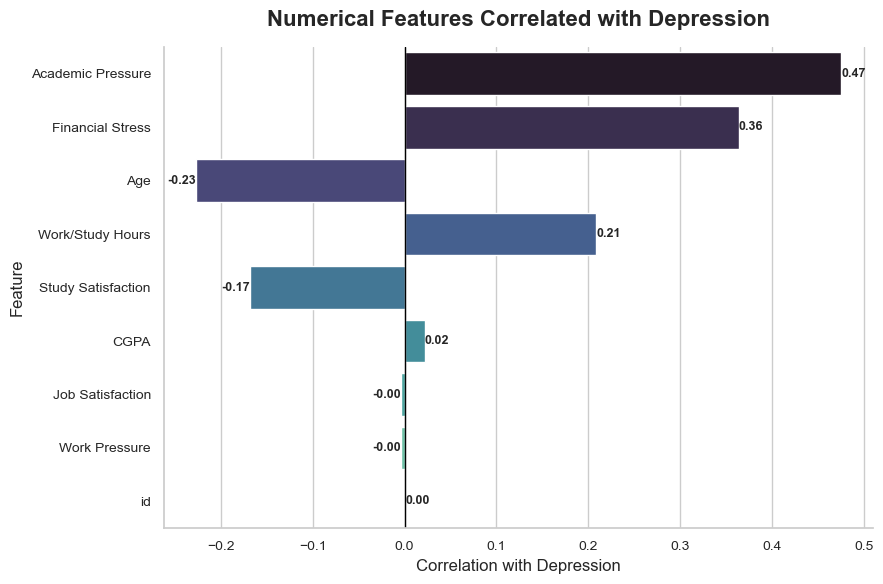

In [ ]:
corr_df = depression_corr.reset_index()
corr_df.columns = ["Feature", "Correlation with Depression"]

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=corr_df,
    y="Feature",
    x="Correlation with Depression",
    hue="Feature",
    palette="mako",
    legend=False
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Numerical Features Correlated with Depression", weight="bold", pad=15)
plt.xlabel("Correlation with Depression")
plt.ylabel("Feature")

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.2f}",
        (width, p.get_y() + p.get_height() / 2),
        ha="left" if width > 0 else "right",
        va="center",
        fontsize=9,
        weight="bold"
    )

sns.despine()
plt.tight_layout()
plt.show()

### Strongest Numerical Relationships with Depression

This chart ranks numerical variables based on their correlation with the target variable `Depression`.

These variables may be important signals for the ANN model, but correlation alone does not prove causation.

# EDA Summary

The Student Depression Dataset contains information about students and different factors that may be related to depression, such as academic pressure, financial stress, sleep duration, study satisfaction, work/study hours and history of suicidal thoughts.

The target variable is `Depression`, where:

- `0` = No depression
- `1` = Depression

This means that the project is a **binary classification problem**.

## Class Balance

The target variable is not extremely imbalanced. Around 58.5% of the students belong to class 1 and around 41.5% belong to class 0. This means that accuracy can be used, but it is still important to also evaluate the model with precision, recall, F1-score and confusion matrix.

## Missing Values

The dataset has very few missing values. Only `Financial Stress` has 3 missing values. Since this is a very small number compared to the full dataset, these values can be handled during preprocessing, for example by using median imputation.

## Important Patterns from EDA

The EDA shows several interesting relationships with depression:

- Students with higher academic pressure seem to have a higher depression rate.
- Students with higher financial stress also seem to have a higher depression rate.
- Students with more work/study hours tend to have a higher depression rate.
- Students who sleep less than 5 hours have the highest depression rate among sleep duration groups.
- Students who answered "Yes" to having had suicidal thoughts have a much higher depression rate.
- Age has a negative correlation with depression, which means that younger students in this dataset seem to have a higher depression rate.
- Study satisfaction has a negative relationship with depression, meaning that lower satisfaction may be connected to higher depression risk.

## Ethical Reflection

This dataset contains sensitive mental health information. Therefore, the model should not be used as a medical diagnosis tool. Instead, it can be seen as a supportive analytical tool to understand risk patterns and help schools or universities plan better student wellbeing support.

## Next Step

The next step is to preprocess the data and build a simple Artificial Neural Network model using TensorFlow/Keras.